In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


# Comparing Models

In [35]:
# Example dictionary of model files
model_files = {
    "Logistic Regression": "Results LogReg no GS.csv",
    "Decision Tree": "Results DTree no GS.csv",
    "Random Forest no GS": "Results RFC no GS.csv",
    "Random Forest GS for F1": "stored_results/Results_RFC_GS_Best_F1.csv",
    "Random Forest GS for Recall": "stored_results/Results_RFC_GS_Best_Recall.csv",
    "Random Forest GS for Recall Stratified KFold": "stored_results/Results_RFC_GS_Best_Recall_Stratified_KFold.csv",
    "Extra Trees": "Results ETC no GS.csv",
    "Gradient Booster": "Results GBC no GS.csv",
    "SVC": "Results SVC no GS.csv",
    "Neural Network": "Results_Neural_Network.csv"
}

In [36]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
)

model_stats = []

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    y_true = df['Hall of Fame']
    y_pred = df['Prediction']

    # Confirm binary labels
    labels = sorted(list(set(y_true) | set(y_pred)))
    print(f"{model_name} labels: {labels}")  # sanity check

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    model_stats.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


results_df_unweighed = pd.DataFrame(model_stats)
results_df_unweighed

Logistic Regression labels: [0, 1]
Decision Tree labels: [0, 1]
Random Forest no GS labels: [0, 1]
Random Forest GS for F1 labels: [0, 1]
Random Forest GS for Recall labels: [0, 1]
Random Forest GS for Recall Stratified KFold labels: [0, 1]
Extra Trees labels: [0, 1]
Gradient Booster labels: [0, 1]
SVC labels: [0, 1]
Neural Network labels: [0, 1]


,Model,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1121,12,29,53,0.966255,0.815385,0.646341,0.721088
1,Decision Tree,1104,29,29,53,0.952263,0.646341,0.646341,0.646341
2,Random Forest no GS,1120,13,30,52,0.964609,0.800000,0.634146,0.707483
3,Random Forest GS for F1,1123,10,32,50,0.965432,0.833333,0.609756,0.704225
4,Random Forest GS for Recall,1123,10,32,50,0.965432,0.833333,0.609756,0.704225
5,Random Forest GS for Recall Stratified KFold,1123,10,31,51,0.966255,0.836066,0.621951,0.713287
6,Extra Trees,1123,10,31,51,0.966255,0.836066,0.621951,0.713287
7,Gradient Booster,1114,19,31,51,0.958848,0.728571,0.621951,0.671053
8,SVC,1124,9,54,28,0.948148,0.756757,0.341463,0.470588
9,Neural Network,1117,16,26,56,0.965432,0.777778,0.682927,0.727273


# Original version. Applied some weighting that made things wrong.

In [12]:
# Store all metrics here
model_stats = []

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    
    # Adjust column names if different
    y_true = df['Hall of Fame']
    y_pred = df['Prediction']
    
    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Compute other metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Append to list
    model_stats.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df_weighed = pd.DataFrame(model_stats)
results_df_weighed

,Model,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1121,12,29,53,0.966255,0.964025,0.966255,0.964430
1,Decision Tree,1104,29,29,53,0.952263,0.952263,0.952263,0.952263
2,Random Forest,1120,13,30,52,0.964609,0.962176,0.964609,0.962694
3,Extra Trees,1123,10,31,51,0.966255,0.963886,0.966255,0.963932
4,Gradient Booster,1114,19,31,51,0.958848,0.956434,0.958848,0.957332
5,SVC,1124,9,54,28,0.948148,0.940837,0.948148,0.938849


# Correct version, matches classification reports from original notebooks.

In [33]:
# Example dictionary of model files
model_files = {
    "Logistic Regression": "Results LogReg no GS.csv",
    "Decision Tree": "Results DTree no GS.csv",
    "Random Forest no GS": "Results RFC no GS.csv",
    "Random Forest GS for F1": "Results_RFC_GS_Best_F1.csv",
    "Random Forest GS for Recall": "Results_RFC_GS_Best_Recall.csv",
    "Random Forest GS for Recall Stratified KFold": "Results_RFC_GS_Best_Recall_Stratified_KFold.csv",
    "Extra Trees": "Results ETC no GS.csv",
    "Gradient Booster": "Results GBC no GS.csv",
    "SVC": "Results SVC no GS.csv",
    "Neural Network": "Results_Neural_Network.csv"
}

In [34]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
)

model_stats = []

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    y_true = df['Hall of Fame']
    y_pred = df['Prediction']

    # Confirm binary labels
    labels = sorted(list(set(y_true) | set(y_pred)))
    print(f"{model_name} labels: {labels}")  # sanity check

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    model_stats.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


results_df_unweighed = pd.DataFrame(model_stats)
results_df_unweighed

Logistic Regression labels: [0, 1]
Decision Tree labels: [0, 1]
Random Forest no GS labels: [0, 1]
Random Forest GS for F1 labels: [0, 1]
Random Forest GS for Recall labels: [0, 1]
Random Forest GS for Recall Stratified KFold labels: [0, 1]
Extra Trees labels: [0, 1]
Gradient Booster labels: [0, 1]
SVC labels: [0, 1]
Neural Network labels: [0, 1]


,Model,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1121,12,29,53,0.966255,0.815385,0.646341,0.721088
1,Decision Tree,1104,29,29,53,0.952263,0.646341,0.646341,0.646341
2,Random Forest no GS,1120,13,30,52,0.964609,0.800000,0.634146,0.707483
3,Random Forest GS for F1,1123,10,32,50,0.965432,0.833333,0.609756,0.704225
4,Random Forest GS for Recall,1123,10,32,50,0.965432,0.833333,0.609756,0.704225
5,Random Forest GS for Recall Stratified KFold,1123,10,31,51,0.966255,0.836066,0.621951,0.713287
6,Extra Trees,1123,10,31,51,0.966255,0.836066,0.621951,0.713287
7,Gradient Booster,1114,19,31,51,0.958848,0.728571,0.621951,0.671053
8,SVC,1124,9,54,28,0.948148,0.756757,0.341463,0.470588
9,Neural Network,1117,16,26,56,0.965432,0.777778,0.682927,0.727273


In [21]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
)

model_stats = []

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    y_true = df['Hall of Fame']
    y_pred = df['Prediction']

    
    # Confirm binary labels
    labels = sorted(list(set(y_true) | set(y_pred)))
    print(f"{model_name} labels: {labels}")  # sanity check

    
    # Optional: if you have probabilities
    y_proba = df['Prediction Confidence'] if 'y_proba' in df.columns else None

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    # Use probabilities if available
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)

    model_stats.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })


results_df_unweighed = pd.DataFrame(model_stats)
results_df_unweighed

Logistic Regression labels: [0, 1]
Decision Tree labels: [0, 1]
Random Forest labels: [0, 1]
Extra Trees labels: [0, 1]
Gradient Booster labels: [0, 1]
SVC labels: [0, 1]


,Model,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1121,12,29,53,0.966255,0.815385,0.646341,0.721088,0.817875
1,Decision Tree,1104,29,29,53,0.952263,0.646341,0.646341,0.646341,0.810373
2,Random Forest,1120,13,30,52,0.964609,0.800000,0.634146,0.707483,0.811336
3,Extra Trees,1123,10,31,51,0.966255,0.836066,0.621951,0.713287,0.806563
4,Gradient Booster,1114,19,31,51,0.958848,0.728571,0.621951,0.671053,0.802591
5,SVC,1124,9,54,28,0.948148,0.756757,0.341463,0.470588,0.666760


# Plot ROC Curves

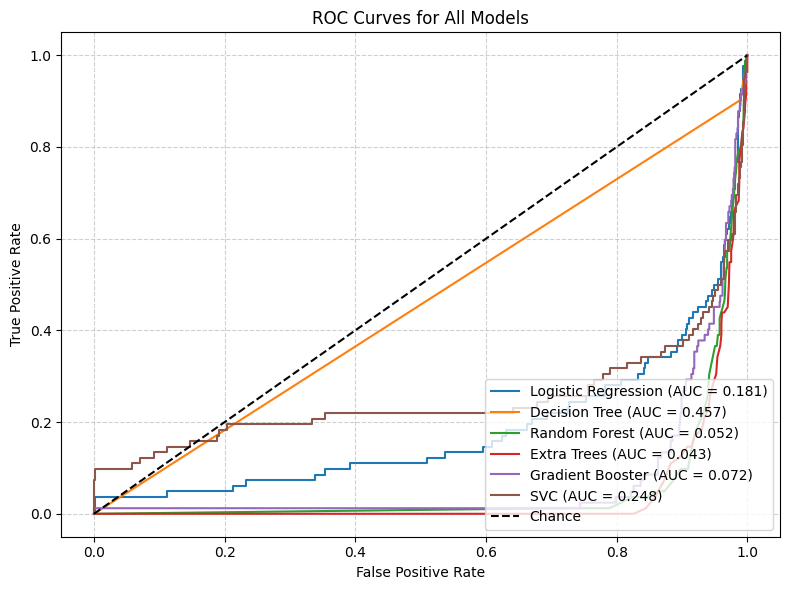

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(8, 6))

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    y_true = df['Hall of Fame']
    
    # Ensure you use the probability of the positive class
    if 'Prediction Confidence' in df.columns:
        y_proba = df['Prediction Confidence']
    elif 'y_prob_1' in df.columns:  # alternate naming
        y_proba = df['y_prob_1']
    else:
        print(f"⚠️ {model_name}: No probabilities found, skipping curve.")
        continue

    # Compute ROC curve points and AUC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Chance')

# Style
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()